# Diabetic Retinopathy Detection — ResNet50 (Transfer Learning)
## Computer Vision Project — UC3M

This notebook fine-tunes **ResNet50** pretrained on ImageNet for binary Diabetic Retinopathy (DR) detection from retinal fundus images.

**Task:** Binary classification — No DR (label 0) vs. DR present (label 1)  
**Evaluation metric:** ROC-AUC  
**Strategy:** Full fine-tuning of all ResNet50 layers with a replaced classification head  
**Best validation AUC achieved:** 0.8346 | Accuracy: 0.8180

## 1. Imports and Configuration

Standard deep learning libraries are imported:
- **PyTorch + torchvision**: model training, pretrained weights, and standard transforms
- **skimage / OpenCV**: image I/O and domain-specific preprocessing
- **scikit-learn**: evaluation metrics (ROC-AUC, accuracy, ROC curve)
- **tqdm**: progress bars during training

A fixed random seed (`seed=42`) is applied across Python, NumPy, and PyTorch to ensure full reproducibility. The device is automatically set to GPU (`cuda:0`) when available, falling back to CPU.

In [26]:
import os
import copy
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim import lr_scheduler
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm
from torchvision import transforms, models

from skimage import io, transform, color
import cv2

from sklearn.metrics import roc_auc_score

import random

# Reproducibility
seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(device)

cuda:0


In [6]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 2. Dataset — `RetinopathyDataset`

A custom PyTorch `Dataset` loads images and labels from a CSV file. Key design decisions:

- **Right-eye normalization:** fundus images are taken of both eyes. Since the optic disc (a key anatomical landmark for DR grading) appears on opposite sides in left vs. right eyes, right-eye images (`eye == 1`) are horizontally flipped so that anatomy is consistently oriented across the full dataset. This prevents the model from learning spurious left/right asymmetry.
- **Binary label conversion:** the original 0–4 severity scale (No DR, Mild, Moderate, Severe, Proliferative DR) is collapsed into a binary problem: `label > 0` → DR-positive. This simplification makes the task tractable with our 2000-image training set and is aligned with the CodaBench evaluation protocol.
- **Optional size cap (`maxSize`):** allows training on a random subset for debugging, using a seeded permutation for reproducibility.

In [7]:
class RetinopathyDataset(Dataset):
    def __init__(self, csv_file, root_dir, transform=None, maxSize=0):
        self.dataset = pd.read_csv(csv_file, dtype={'id': str, 'eye': int, 'label': int})

        if maxSize > 0:
            idx = np.random.RandomState(seed=42).permutation(len(self.dataset))
            self.dataset = self.dataset.iloc[idx[:maxSize]].reset_index(drop=True)

        self.root_dir = root_dir
        self.img_dir = os.path.join(root_dir, 'images')
        self.transform = transform

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        row = self.dataset.iloc[idx]
        img_path = os.path.join(self.img_dir, row.id + '.jpg')
        image = io.imread(img_path)

        if row.eye == 1:
            image = image[:, ::-1, :]

        label = int(row.label > 0)

        sample = {'image': image, 'label': label}

        if self.transform:
            sample = self.transform(sample)

        return sample

## 3. Custom Preprocessing Transforms

A fully custom transform pipeline is implemented using PyTorch's callable-object convention, because fundus images require domain-specific preprocessing unavailable in standard torchvision transforms.

### `CropByEye`
Fundus photographs typically have large black borders outside the circular retinal region (an artifact of the fundus camera optics). This transform applies OpenCV binary thresholding on the grayscale image to generate a foreground mask and crops tightly to the bounding box of the detected eye region. This removes uninformative background pixels, ensures the model focuses on retinal tissue, and standardizes the spatial input across different imaging setups. A small border margin avoids accidentally clipping retinal edges.

### `Rescale`
Proportionally resizes the (potentially non-square) cropped image so that the shorter side reaches the target size. Preserving aspect ratio avoids distorting the retinal geometry before the final center crop.

### `ToTensor`
Transposes the H×W×C NumPy array (float32 in [0,1]) to C×H×W format and wraps it as a PyTorch tensor, as required by PyTorch convolution layers.

In [8]:
class CropByEye(object):
    def __init__(self, threshold, border):
        self.threshold = threshold
        self.border = (border, border) if isinstance(border, int) else border

    def __call__(self, sample):
        image, label = sample['image'], sample['label']
        h, w = image.shape[:2]

        gray = color.rgb2gray(image)
        _, mask = cv2.threshold(gray, self.threshold, 1, cv2.THRESH_BINARY)

        sidx = np.nonzero(mask)
        if len(sidx[0]) < 20:
            return sample

        minx = max(sidx[1].min() - self.border[1], 0)
        maxx = min(sidx[1].max() + self.border[1], w)
        miny = max(sidx[0].min() - self.border[0], 0)
        maxy = min(sidx[0].max() + self.border[0], h)

        image = image[miny:maxy, minx:maxx]

        return {'image': image, 'label': label}


class Rescale(object):
    def __init__(self, size):
        self.size = size

    def __call__(self, sample):
        image, label = sample['image'], sample['label']
        image = transform.resize(image, (self.size, self.size))
        return {'image': image, 'label': label}


class ToTensor(object):
    def __call__(self, sample):
        image, label = sample['image'], sample['label']
        image = image.transpose((2, 0, 1))
        return {
            'image': torch.tensor(image, dtype=torch.float32),
            'label': torch.tensor(label, dtype=torch.float32)
        }

## 4. Data Augmentation

Augmentation is applied **only during training** to increase effective dataset diversity and reduce overfitting. The chosen augmentations reflect realistic variability in clinical fundus photography:

- **Random horizontal flip (p=0.5):** valid because both eyes are already normalized to the same orientation via the right-eye mirroring in `RetinopathyDataset`. Horizontal flips do not alter clinical meaningfulness.
- **Random rotation (±10°):** fundus cameras may be slightly rotated relative to the patient's eye axis — small rotations simulate this natural variability without introducing implausible distortions.
- **Color jitter (brightness ±0.2, contrast ±0.2):** different fundus cameras and imaging environments produce varying illumination and contrast. Mild photometric perturbation makes the model robust to these equipment-level differences.

`TVAugment` wraps `torchvision.transforms` and integrates them into our custom dictionary-based pipeline.

In [9]:
class ToPIL(object):
    def __call__(self, sample):
        from PIL import Image
        image, label = sample['image'], sample['label']
        return {'image': Image.fromarray((image * 255).astype(np.uint8)), 'label': label}


class FromPIL(object):
    def __call__(self, sample):
        image, label = sample['image'], sample['label']
        return {'image': np.array(image) / 255.0, 'label': label}

In [10]:
class TVAugment(object):
    def __init__(self):
        from torchvision import transforms

        self.augment = transforms.Compose([
            transforms.RandomHorizontalFlip(),
            transforms.RandomRotation(10),
            transforms.ColorJitter(brightness=0.2, contrast=0.2)
        ])

    def __call__(self, sample):
        from PIL import Image

        image, label = sample['image'], sample['label']

        if image.max() <= 1:
            image = (image * 255).astype(np.uint8)
        else:
            image = image.astype(np.uint8)

        pil = Image.fromarray(image)
        pil = self.augment(pil)

        image = np.array(pil).astype(np.float32) / 255.0

        return {'image': image, 'label': label}

In [11]:
class CenterCrop(object):
    def __init__(self, size):
        self.size = size

    def __call__(self, sample):
        image, label = sample['image'], sample['label']
        h, w = image.shape[:2]
        new_h, new_w = self.size, self.size

        top = max((h - new_h) // 2, 0)
        left = max((w - new_w) // 2, 0)

        image = image[top:top+new_h, left:left+new_w]

        return {'image': image, 'label': label}

In [12]:
class Normalize(object):
    def __init__(self, mean, std):
        self.mean = np.array(mean)
        self.std = np.array(std)

    def __call__(self, sample):
        image, label = sample['image'], sample['label']
        c, h, w = image.shape

        mean = torch.tensor(self.mean, dtype=image.dtype)
        std = torch.tensor(self.std, dtype=image.dtype)

        image = (image - mean[:, None, None]) / std[:, None, None]

        return {'image': image, 'label': label}

In [13]:
class Rescale(object):
    def __init__(self, size):
        self.size = size

    def __call__(self, sample):
        image, label = sample['image'], sample['label']
        h, w = image.shape[:2]

        if h > w:
            new_h = int(self.size * h / w)
            new_w = self.size
        else:
            new_h = self.size
            new_w = int(self.size * w / h)

        image = transform.resize(image, (new_h, new_w))

        return {'image': image, 'label': label}

## 5. Transform Pipelines

Two separate pipelines are defined:

- **`train_transform`:** includes random augmentation (flip, rotation, color jitter) applied after eye cropping and resizing — used only during training
- **`val_transform`:** fully deterministic — only crop, resize, center crop, and normalize — used for validation, testing, and final prediction to guarantee consistent, reproducible outputs

Both pipelines apply **ImageNet normalization** (`mean=[0.485, 0.456, 0.406]`, `std=[0.229, 0.224, 0.225]`). This is standard practice when fine-tuning ImageNet-pretrained models: it aligns the input distribution of our fundus images with the distribution the pretrained weights were optimized for.

In [14]:
pixel_mean = [0.485, 0.456, 0.406]
pixel_std = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    CropByEye(0.10, 1),
    Rescale(256),
    TVAugment(),
    CenterCrop(224),
    ToTensor(),
    Normalize(pixel_mean, pixel_std)
])

val_transform = transforms.Compose([
    CropByEye(0.10, 1),
    Rescale(256),
    CenterCrop(224),
    ToTensor(),
    Normalize(pixel_mean, pixel_std)
])

## 6. Data Loaders

Three `DataLoader` instances are created for training, validation, and test splits:
- **Train:** `batch_size=32`, `shuffle=True` — shuffling prevents the model from memorizing sample ordering across epochs
- **Val / Test:** `batch_size=64`, `shuffle=False` — deterministic order ensures consistent epoch-level evaluation

**Class imbalance note:** the training set contains ~1468 negative (No DR) and ~532 positive (DR) samples (~73% vs ~27%). Without correction, a model could achieve 73% accuracy by predicting the majority class. Some models address this with `WeightedRandomSampler` in the next cell.

In [15]:
data_dir = "/content/drive/MyDrive/CV/Project2/data"

train_dataset = RetinopathyDataset(
    os.path.join(data_dir, "train.csv"),
    data_dir,
    transform=train_transform
)

val_dataset = RetinopathyDataset(
    os.path.join(data_dir, "val.csv"),
    data_dir,
    transform=val_transform
)

test_dataset = RetinopathyDataset(
    os.path.join(data_dir, "test.csv"),
    data_dir,
    transform=val_transform
)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

## 8. Model Architecture — ResNet50 (Fine-Tuning)

**ResNet50** (He et al., 2016) is a 50-layer convolutional network featuring **residual (skip) connections** that allow gradients to flow directly across layers. This addresses the vanishing gradient problem and enables training of deep networks. Pretrained on ImageNet (1.28M images, 1000 classes).

**Architecture adaptation for DR detection:**
- The original final fully-connected layer (2048 → 1000 classes) is replaced with a single linear unit (2048 → 1), outputting a single raw logit for binary classification
- No sigmoid activation is applied in the forward pass — `BCEWithLogitsLoss` combines sigmoid and BCE internally for improved numerical stability
- **Full fine-tuning:** all layers remain trainable, appropriate because the 2000-image dataset is large enough to avoid catastrophic forgetting when using a small learning rate, and because ImageNet features transfer well to retinal images

In [16]:
model = models.resnet50(pretrained=True)

num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, 1)

model = model.to(device)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 115MB/s]


## 9. Loss Function, Optimizer, and Scheduler

- **Loss:** `BCEWithLogitsLoss` — numerically stable binary cross-entropy; applies sigmoid internally. Standard choice when no class weighting is needed (ResNet uses full fine-tuning, which provides implicit regularization).
- **Optimizer:** `Adam` with `lr=1e-4` — adaptive learning rate, well-suited for fine-tuning where different layers may require different effective learning rates
- **Scheduler:** `StepLR` decays the learning rate by a factor of 0.1 every 10 epochs, allowing larger updates early in training and more conservative fine-grained updates near convergence

In [17]:
criterion = nn.BCEWithLogitsLoss()

optimizer = optim.Adam(model.parameters(), lr=1e-4)

scheduler = lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.1)

## 11. Training Loop with Early Stopping

The `train_model` function implements the full training procedure with early stopping. Key design decisions:

- **Primary metric: ROC-AUC** — used instead of accuracy because it is threshold-independent and handles class imbalance robustly. A naive majority-class predictor achieves ~73% accuracy but only AUC ~0.5, making AUC a far more informative signal.
- **Early stopping (patience=10):** training halts if validation AUC does not improve for 10 consecutive epochs, preventing overfitting and avoiding unnecessary GPU compute.
- **Best-model checkpointing:** model weights achieving the highest validation AUC are saved to disk after every improvement and restored at the end of training. This ensures the returned model is the global best — not just the final epoch.
- **LR scheduler step:** called at the end of each epoch to decay the learning rate according to the chosen schedule, enabling fine-grained convergence near the optimum.

In [18]:
def train_model(model, patience=10, num_epochs=100):
    best_auc = 0
    counter = 0
    best_weights = copy.deepcopy(model.state_dict())

    train_losses = []
    val_losses = []
    val_aucs = []

    for epoch in range(num_epochs):
        print(f"\nEpoch {epoch+1}/{num_epochs}")

        # ===================== TRAIN =====================
        model.train()
        running_loss = 0

        train_bar = tqdm(train_loader, desc="Training", leave=False)

        for batch in train_bar:
            inputs = batch['image'].to(device)
            labels = batch['label'].to(device)

            optimizer.zero_grad()
            outputs = model(inputs).squeeze()
            loss = criterion(outputs, labels)

            loss.backward()
            optimizer.step()

            running_loss += loss.item() * inputs.size(0)

            # Update barra
            train_bar.set_postfix(loss=loss.item())

        epoch_train_loss = running_loss / len(train_dataset)
        train_losses.append(epoch_train_loss)

        # ===================== VALIDATION =====================
        model.eval()
        outputs_all = []
        labels_all = []
        val_loss = 0

        val_bar = tqdm(val_loader, desc="Validation", leave=False)

        with torch.no_grad():
            for batch in val_bar:
                inputs = batch['image'].to(device)
                labels = batch['label'].to(device)

                outputs = model(inputs).squeeze()
                loss = criterion(outputs, labels)

                val_loss += loss.item() * inputs.size(0)

                outputs_all.extend(torch.sigmoid(outputs).cpu().numpy())
                labels_all.extend(labels.cpu().numpy())

                val_bar.set_postfix(loss=loss.item())

        epoch_val_loss = val_loss / len(val_dataset)
        val_losses.append(epoch_val_loss)

        auc = roc_auc_score(labels_all, outputs_all)
        val_aucs.append(auc)

        print(f"Train Loss: {epoch_train_loss:.4f} | Val Loss: {epoch_val_loss:.4f} | AUC: {auc:.4f}")

        # ===================== EARLY STOPPING =====================
        if auc > best_auc:
            best_auc = auc
            best_weights = copy.deepcopy(model.state_dict())
            torch.save(best_weights, "best_model_resnet50.pth")
            counter = 0
            print("New best model!")
        else:
            counter += 1
            print(f"Patience: {counter}/{patience}")

        if counter >= patience:
            print("Early stopping triggered")
            break

        scheduler.step()

    model.load_state_dict(best_weights)

    return model, train_losses, val_losses, val_aucs

## 12. Training

The model is trained by calling `train_model`. The function returns the best model (by validation AUC), along with per-epoch training/validation losses and validation AUC values. These are plotted below to diagnose convergence:
- A decreasing training loss with stable validation loss → healthy learning
- A diverging gap between train and val loss → overfitting (check augmentation / regularization)
- A plateau in both curves → learning rate may need reduction

In [19]:
model, train_losses, val_losses, val_aucs = train_model(model)


Epoch 1/100


Train Loss: 0.5431 | Val Loss: 0.7006 | AUC: 0.7928
New best model!

Epoch 2/100


Train Loss: 0.4451 | Val Loss: 0.4478 | AUC: 0.7863
Patience: 1/10

Epoch 3/100


Train Loss: 0.3883 | Val Loss: 0.4583 | AUC: 0.8011
New best model!

Epoch 4/100


Train Loss: 0.3302 | Val Loss: 0.4962 | AUC: 0.7865
Patience: 1/10

Epoch 5/100


...

Train Loss: 0.0329 | Val Loss: 0.6424 | AUC: 0.8302
Patience: 6/10

Epoch 21/100


Train Loss: 0.0284 | Val Loss: 0.6334 | AUC: 0.8288
Patience: 7/10

Epoch 22/100


Train Loss: 0.0305 | Val Loss: 0.6643 | AUC: 0.8294
Patience: 8/10

Epoch 23/100


Train Loss: 0.0266 | Val Loss: 0.6242 | AUC: 0.8283
Patience: 9/10

Epoch 24/100


Train Loss: 0.0222 | Val Loss: 0.6475 | AUC: 0.8287
Patience: 10/10
Early stopping triggered


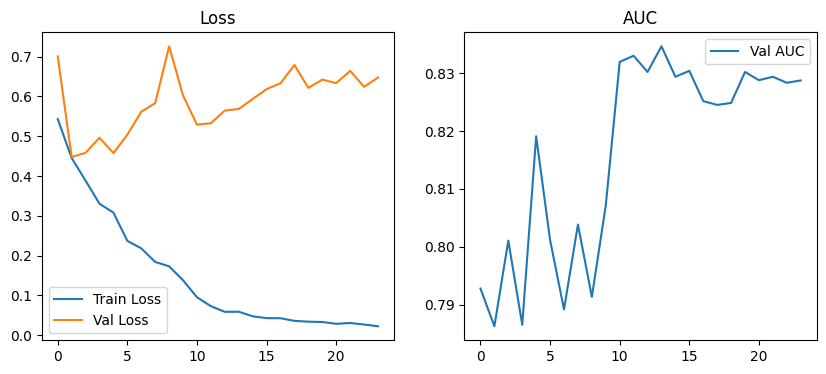

In [20]:
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Val Loss")
plt.legend()
plt.title("Loss")

plt.subplot(1,2,2)
plt.plot(val_aucs, label="Val AUC")
plt.legend()
plt.title("AUC")

plt.show()

## 13. Evaluation on Validation Set

Final performance is computed on the full 500-image validation set using the best-checkpoint model:

- **ROC-AUC:** primary metric — measures the model's ability to rank positive samples above negative ones, independent of the decision threshold. An AUC of 1.0 is perfect; 0.5 is random.
- **Accuracy:** secondary metric, computed at the standard 0.5 threshold for interpretability
- **ROC curve:** visualizes the sensitivity (true positive rate) vs. 1-specificity (false positive rate) trade-off across all possible decision thresholds, useful for understanding clinical operating points

In [21]:
from sklearn.metrics import roc_auc_score, accuracy_score

def evaluate_model(model, loader):
    model.eval()

    outputs_all = []
    labels_all = []

    with torch.no_grad():
        for batch in loader:
            inputs = batch['image'].to(device)
            labels = batch['label'].to(device)

            outputs = model(inputs).squeeze()
            probs = torch.sigmoid(outputs)

            outputs_all.extend(probs.cpu().numpy())
            labels_all.extend(labels.cpu().numpy())

    outputs_all = np.array(outputs_all)
    labels_all = np.array(labels_all)

    auc = roc_auc_score(labels_all, outputs_all)

    # Convert to binary predictions
    preds = (outputs_all > 0.5).astype(int)
    acc = accuracy_score(labels_all, preds)

    return auc, acc

In [22]:
val_auc, val_acc = evaluate_model(model, val_loader)

print(f"Validation AUC: {val_auc:.4f}")
print(f"Validation Accuracy: {val_acc:.4f}")

Validation AUC: 0.8346
Validation Accuracy: 0.8180


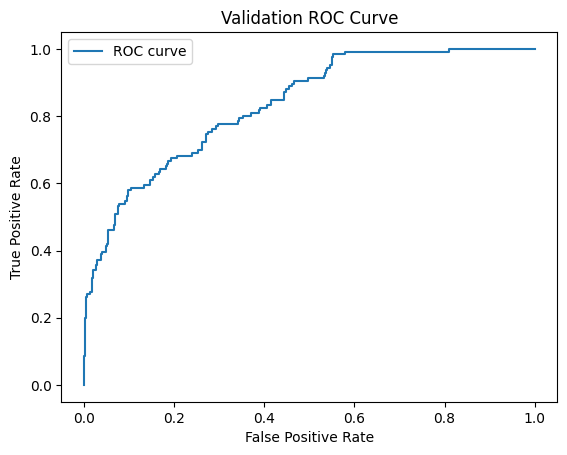

In [23]:
from sklearn.metrics import roc_curve

def plot_roc(model, loader):
    model.eval()

    outputs_all = []
    labels_all = []

    with torch.no_grad():
        for batch in loader:
            inputs = batch['image'].to(device)
            labels = batch['label'].to(device)

            outputs = torch.sigmoid(model(inputs).squeeze())

            outputs_all.extend(outputs.cpu().numpy())
            labels_all.extend(labels.cpu().numpy())

    fpr, tpr, _ = roc_curve(labels_all, outputs_all)

    plt.plot(fpr, tpr, label="ROC curve")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("Validation ROC Curve")
    plt.legend()
    plt.show()
plot_roc(model, val_loader)

## 14. Test Set Predictions

The trained model generates probability scores for all 1000 test set images (labels unavailable). Raw logits are passed through `torch.sigmoid` to produce probabilities in [0, 1], which are saved to a CSV file. These individual model predictions will be combined with other models in the stacking ensemble to produce the final CodaBench submission.

In [24]:
def predict(model, loader):
    model.eval()
    outputs = []

    with torch.no_grad():
        for batch in loader:
            inputs = batch['image'].to(device)
            preds = torch.sigmoid(model(inputs).squeeze())
            outputs.extend(preds.cpu().numpy())

    return np.array(outputs)

test_outputs = predict(model, test_loader)

In [25]:
import csv

with open("resnet50_baseline.csv", "w") as f:
    writer = csv.writer(f)
    for val in test_outputs:
        writer.writerow([val])